In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [17]:
def create_grid(domain_size_x, domain_size_y, num_points):
    
    x_grid, y_grid = np.meshgrid(
        np.linspace(1e-20, domain_size_x, num_points), # Начинаем не с 0 что бы избежать деления на 0
        np.linspace(-domain_size_y, domain_size_y, 2 * num_points)
    )
    return x_grid, y_grid

def plot(x_grid, y_grid, concentration: np.ndarray, min_concentration: float, fill: bool = True) -> None:
    """
    Отрисовывает график концентрации.

    :param x_grid: Сетка по оси X.
    :param y_grid: Сетка по оси Y.
    :param concentration: Массив концентраций.
    :param min_concentration: Минимальное значение концентрации для отображения.
    :param fill: Заливка графика, True по умолчанию.
    """
    concentration = np.where(concentration <= 0, 1e-50, concentration)
    levels = np.geomspace(min_concentration, concentration.max(), 20)  # Логарифмические уровни
    if fill:
        plt.contourf(
            x_grid, y_grid, concentration,
            levels=levels,
            cmap='cividis',  # Цветовая карта
            norm=LogNorm(vmin=min_concentration, vmax=concentration.max()),  # Логарифмическая нормализация
        )
    else:
        plt.contour(
            x_grid, y_grid, concentration,
            levels=levels,
            cmap='cividis',  # Цветовая карта
            norm=LogNorm(vmin=min_concentration, vmax=concentration.max()),  # Логарифмическая нормализация
            linewidths=1  # Толщина линий
        )
    cbar = plt.colorbar()
    cbar.ax.set_yscale('log')
    return plt


In [16]:
domain_size_x, domain_size_y = 1000, 1000
num_points = 1000

Q=10            # Интенсивность источника
x0, y0=100, 0   # Координаты источника
u, v =2.0, 0    # Скорость ветра
mu=1            # Коэффициент турбулентной диффузии
sigma=0.05      # Коэффициент поглощения

# Создание сетки
x_grid, y_grid = create_grid(domain_size_x, domain_size_y, num_points)

In [20]:
dx = x_grid - x0
dy = y_grid - y0
dr = np.sqrt(dx**2 + dy**2)

beta = sigma + (u**2 + v**2) / (4 * mu)
x_val = np.sqrt(beta / mu) * dr

uv_dot = u * dx + v * dy
concentration = np.zeros_like(x_val)

# Случай x_val < 2
mask_lt2 = x_val < 2
x_lt2 = x_val[mask_lt2]
if x_lt2.size > 0:
    tilde_x1 = x_lt2 / 2
    t = x_lt2 / 3.75
    alpha = (1 + 3.5156229 * t**2 + 3.0899424 * t**4 +
                1.2067492 * t**6 + 0.2659732 * t**8 +
                0.0360768 * t**10 + 0.0045813 * t**12)
    ln_tilde_x1 = np.log(tilde_x1)
    tilde_k1 = (-alpha * ln_tilde_x1 - 0.5721566 +
                0.4227842 * tilde_x1**2 + 0.23069756 * tilde_x1**4 +
                0.0348589 * tilde_x1**6 + 0.00262698 * tilde_x1**8 +
                0.0001075 * tilde_x1**10 + 0.000074 * tilde_x1**12)
    exp_factor = np.exp((u * dx[mask_lt2] + v * dy[mask_lt2]) / (2 * mu))
    concentration[mask_lt2] = (Q / (2 * np.pi * mu)) * tilde_k1 * exp_factor

# Случай x_val >= 2
mask_ge2 = ~mask_lt2
x_ge2 = x_val[mask_ge2]
if x_ge2.size > 0:
    tilde_x2 = 2 / x_ge2
    tilde_k2 = (1.25331414 - 0.07832358 * tilde_x2 +
                0.02189568 * tilde_x2**2 - 0.01062446 * tilde_x2**3 +
                0.00587872 * tilde_x2**4 - 0.0025154 * tilde_x2**5 +
                0.000532 * tilde_x2**6)
    exp_factor_ge2 = np.exp((u * dx[mask_ge2] + v * dy[mask_ge2]) / (2 * mu) - x_ge2)
    concentration[mask_ge2] = (Q / (2 * x_ge2 * np.pi * mu)) * tilde_k2 * exp_factor_ge2


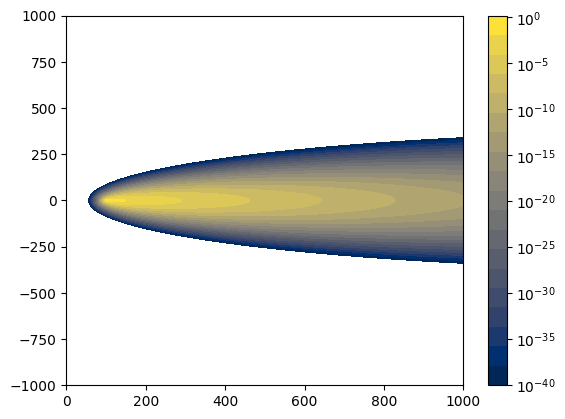

In [24]:
# Визуализация
plt = plot(x_grid, y_grid, concentration, min_concentration=1e-40)
plt.show()